In [29]:
import geopandas as gpd
import pandas as pd
import os, json, xmltodict, math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib
import load_data_new_type as ld
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

In [33]:
shapefile_path = os.path.join(os.getcwd(), "shapefile")

#cwbxml
with open(os.getcwd()+"\\xml\\4-18-2.xml", encoding="utf-8") as xml_file:
    data_dict = xmltodict.parse(xml_file.read())
    cwb_data = json.loads(json.dumps(data_dict, ensure_ascii=False).encode("utf-8").decode())
    Identifier = cwb_data["earthquake"]["identifier"]
    Schemaver = cwb_data["earthquake"]["schemaVer"]
    Language = cwb_data["earthquake"]["language"]
    Sendername = cwb_data["earthquake"]["senderName"]
    Senttime = cwb_data["earthquake"]["sent"]
    Status = cwb_data["earthquake"]["status"]
    Msgtype = cwb_data["earthquake"]["msgType"]
    MsgNo = cwb_data["earthquake"]["msgNo"]
    Description = cwb_data["earthquake"]["description"]
    Origintime = cwb_data["earthquake"]["originTime"]
    Lat = float(cwb_data["earthquake"]["epicenter"]["epicenterLat"]["#text"])
    Lon = float(cwb_data["earthquake"]["epicenter"]["epicenterLon"]["#text"])
    Depth = cwb_data["earthquake"]["depth"]["#text"]
    Magnitude = cwb_data["earthquake"]["magnitude"]["magnitudeValue"]
    pgaAdj = cwb_data["earthquake"]["pgaAdj"]

    cwb_origin_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp() 
    replay_start_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp() - 3.1
    print(replay_start_time, cwb_origin_time)
    print(datetime.fromtimestamp(replay_start_time))

1618755276.9 1618755280.0
2021-04-18 22:14:36.900000


In [34]:
town = gpd.read_file(shapefile_path+"\TOWN_MOI_1091016.shp", encoding="utf-8")
county = gpd.read_file(shapefile_path+"\COUNTY_MOI_1090820.shp", encoding="utf-8")
crs = county.crs

# variables #
#data
mqtt_data = "4.18//Alarms_026.json"
site_data = "4.18//Sites_026.json"
trigger_site = []
trigger_cwb = []
site_calculate = []
sp_site = ["S00049"]

frame_rate = 0.1 #10 frame/per second
s_radius = 0.045 
p_radius = 0.055

#zero point
origin_x = 119 
origin_y = 21.8 
delta_x = 3.3 
delta_y = 3.7

t_size = 20 #text size

cbw = 2.3 #county_boundary_width
tbw = 0.5 #town_boundary_width

#eq_data
data = ld.load_data(mqtt_data)

#site_data
site_df = ld.load_site(site_data)
site_df["Calculate_Time"] = ""
#print(site_df)
for index, row in site_df.iterrows():
    if row["Site_ID"] in sp_site:
        time_tmp = row["Trigger_Time"] - timedelta(seconds=1)
        site_df.iloc[index, site_df.columns.get_loc("Calculate_Time")] = time_tmp

    else:
        time_tmp = row["Trigger_Time"] - timedelta(seconds=3)
        site_df.iloc[index, site_df.columns.get_loc("Calculate_Time")] = time_tmp
#print(site_df)
site_geo = gpd.GeoDataFrame(site_df, geometry=gpd.points_from_xy(site_df.Site_Lon, site_df.Site_Lat))
site_geo

#for ind, row in site_geo.iterrows():
    #print(ind,row["Site_ID"])
#Datetime = list(set(site_df.Datetime.tolist()))
#Trigger_Time = list(set(site_df.Trigger_Time.tolist()))
#Datetime.sort()
#Trigger_Time.sort()

#site_times = {
#        "Datetime":Datetime,
#        "Trigger_Time":Trigger_Time
#}



,Site_ID,Site_Lat,Site_Lon,Site_Level,PGAx,Trigger_Time,Calculate_Time,geometry
0,S00019,23.9630,121.5687,5+,189.912100,2021-04-18 22:14:45.255,2021-04-18 22:14:42.255000,POINT (121.56870 23.96300)
1,S00048,23.5210,121.4000,6-,284.179200,2021-04-18 22:14:47.324,2021-04-18 22:14:44.324000,POINT (121.40000 23.52100)
2,S00105,24.0290,121.1350,5-,131.786100,2021-04-18 22:14:48.723,2021-04-18 22:14:45.723000,POINT (121.13500 24.02900)
3,S00104,23.9800,120.9610,5-,124.268500,2021-04-18 22:14:50.604,2021-04-18 22:14:47.604000,POINT (120.96100 23.98000)
4,S00007,23.4171,121.3710,3,17.296640,2021-04-18 22:14:51.582,2021-04-18 22:14:48.582000,POINT (121.37100 23.41710)
5,S00021,23.8370,120.9025,3,22.055350,2021-04-18 22:14:52.561,2021-04-18 22:14:49.561000,POINT (120.90250 23.83700)
6,S00117,24.4380,121.3810,4,46.618360,2021-04-18 22:14:53.129,2021-04-18 22:14:50.129000,POINT (121.38100 24.43800)
7,S00083,24.0278,120.8252,3,23.415560,2021-04-18 22:14:53.326,2021-04-18 22:14:50.326000,POINT (120.82520 24.02780)
8,S00087,23.5938,120.8884,3,16.059760,2021-04-18 22:14:53.829,2021-04-18 22:14:50.829000,POINT (120.88840 23.59380)
9,S00086,23.7428,120.7810,4,35.693510,2021-04-18 22:14:55.907,2021-04-18 22:14:52.907000,POINT (120.78100 23.74280)


2021-04-18 22:14:37
2021-04-18 22:14:37.100000
2021-04-18 22:14:37.200000
2021-04-18 22:14:37.300000
2021-04-18 22:14:37.400000
2021-04-18 22:14:37.500000
2021-04-18 22:14:37.600000
2021-04-18 22:14:37.700000
2021-04-18 22:14:37.800000
2021-04-18 22:14:37.900000
2021-04-18 22:14:38
2021-04-18 22:14:38.100000
2021-04-18 22:14:38.200000
2021-04-18 22:14:38.300000
2021-04-18 22:14:38.400000
2021-04-18 22:14:38.500000
2021-04-18 22:14:38.600000
2021-04-18 22:14:38.700000
2021-04-18 22:14:38.800000
2021-04-18 22:14:38.900000
2021-04-18 22:14:39
2021-04-18 22:14:39.100000
2021-04-18 22:14:39.200000
2021-04-18 22:14:39.300000
2021-04-18 22:14:39.400000
2021-04-18 22:14:39.500000
2021-04-18 22:14:39.600000
2021-04-18 22:14:39.700000
2021-04-18 22:14:39.800000
2021-04-18 22:14:39.900000
2021-04-18 22:14:40
2021-04-18 22:14:40.100000
-----end before event-------
2021-04-18 22:14:40.200000
2021-04-18 22:14:40.300000
2021-04-18 22:14:40.400000
2021-04-18 22:14:40.500000
2021-04-18 22:14:40.600000


['S00019', 'S00048', 'S00105', 'S00104', 'S00007', 'S00021', 'S00117', 'S00083']
2021-04-18 22:14:50.400000
空格產生完畢，繼續產出資料圖片 2021-04-18 22:14:50.400000
<class 'dict'>
calculating list: ['S00019', 'S00048', 'S00105', 'S00104', 'S00007', 'S00021', 'S00117', 'S00083']
replay_time: 2021-04-18 22:14:50.400000
1: S00019
2: S00019
site Triggered
already in
1: S00048
2: S00048
site Triggered
already in
1: S00105
2: S00105
site Triggered
1: S00104
2: S00104
2021-04-18 22:14:50.400000 2021-04-18 22:14:50.604000
1: S00007
2: S00007
2021-04-18 22:14:50.400000 2021-04-18 22:14:51.582000
1: S00021
2: S00021
2021-04-18 22:14:50.400000 2021-04-18 22:14:52.561000
1: S00117
2: S00117
2021-04-18 22:14:50.400000 2021-04-18 22:14:53.129000
1: S00083
2: S00083
2021-04-18 22:14:50.400000 2021-04-18 22:14:53.326000
1: S00087
1: S00086
1: S00081
1: S00102
1: S00023
1: S00088
1: S00098
1: S00075
1: S00074
1: S00078
1: S00069
1: S00043
1: S00055
1: S00068
1: S00096
1: S00099
1: S00014
1: S00101
1: S00103
1: S0009

2021-04-18 22:14:56.900000
2021-04-18 22:14:57
calculating
   Site_ID  Site_Lat  Site_Lon Site_Level      PGAx            Trigger_Time  \
13  S00088   24.4254  120.7277         5-  95.10772 2021-04-18 22:15:00.038   

                Calculate_Time                    geometry  
13  2021-04-18 22:14:57.038000  POINT (120.72770 24.42540)  
['S00019', 'S00048', 'S00105', 'S00104', 'S00007', 'S00021', 'S00117', 'S00083', 'S00087', 'S00086', 'S00081', 'S00102', 'S00023', 'S00088']
calculating
   Site_ID  Site_Lat  Site_Lon Site_Level      PGAx            Trigger_Time  \
14  S00098   24.7283  121.2263          4  26.60617 2021-04-18 22:15:00.060   

                Calculate_Time                    geometry  
14  2021-04-18 22:14:57.060000  POINT (121.22630 24.72830)  


KeyboardInterrupt: 

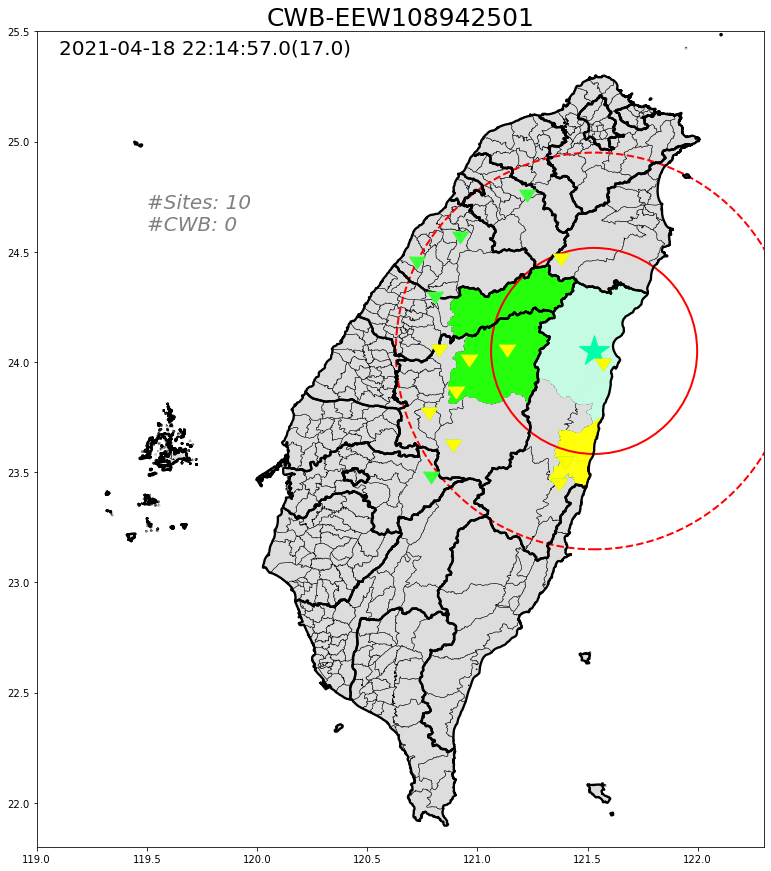

In [37]:
#plotting eq data
color_map = [
        '#C4FBE2',
        '#26FF0B',
        '#FFFE0B',
        '#FF810B',
        '#FF550B',
        '#AC1F14',
        '#A92700',
        '#983476',
        '#BB20D9'
]
cLevel = [1, 2, 3, 4, 5, 5.5, 6, 6.5, 7]
cmap, norm = matplotlib.colors.from_levels_and_colors(cLevel, color_map, extend="max")

#norm = matplotlib.colors.BoundaryNorm(cLevel,9)
#norm = matplotlib.colors.Normalize(vmin=1, vmax=7, clip=True)
#cm = matplotlib.colors.ListedColormap(color_map)
#cmap1 = LinearSegmentedColormap.from_list("my_colormap", color_map, N=9, gamma=1.0)


#map init
f, axes = plt.subplots(figsize=(15,15))
axes.set_title(Identifier, fontsize=25)
county.boundary.plot(ax=axes, color="black", edgecolor="black",linewidth=cbw, zorder=2)  #draw counties
l1 = town.plot(ax=axes, color="#dddddd", edgecolor="black", linewidth=tbw, zorder=1)     #draw towns
    
#set pic location
minx, miny, maxx, maxy = (origin_x, origin_y, origin_x + delta_x, origin_y + delta_y)
l1.set_xlim(minx, maxx)
l1.set_ylim(miny, maxy)
#event_time = (datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00"))
replay_time = datetime.fromtimestamp(replay_start_time)

#TextBoxes
axes_time = axes.text(minx+0.1, maxy-0.1, replay_time, size=t_size)
axes_site_count = axes.text(119.5, 24.7, "#Sites: "+str(len(trigger_site)), size=t_size, style='italic', c="gray")
axes_cwb_count = axes.text(119.5, 24.6, "#CWB: "+str(len(trigger_cwb)), size=t_size, style='italic', c="gray")


#plotting eq_center
eq_center = pd.DataFrame({"Name":"eq_center", "Latitude":[Lat], "Longitude":[Lon]})
eq_center = gpd.GeoDataFrame(eq_center, geometry=gpd.points_from_xy(eq_center.Longitude, eq_center.Latitude))
eq_center.plot(ax=axes, color="#00ffaa", marker="*", markersize=1000, zorder=3)
op = 0 #temproary

#before_event_process
while replay_time <= datetime.fromtimestamp(cwb_origin_time):
    replay_time += timedelta(seconds=frame_rate)
    print(replay_time)
    replay_time_str = replay_time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-5]
    axes.texts[-3].set_text((replay_time_str.replace("_",":")+ "({})".format(round(replay_time.timestamp() - cwb_origin_time ,2))))
        
    #print(texts)
    axes.plot()
    axes.figure.savefig(replay_time_str+".png")
print("-----end before event-------")
p_radius, s_radius, replay_time, site_calculate, trigger_cwb = gen_gap_frame(axes, replay_time, cwb_origin_time, site_geo, gap_list, frame_rate, axes.texts, p_radius, s_radius, trigger_site, site_calculate, trigger_cwb)

print("空格產生完畢，開始產生資料圖片",replay_time)
for item in data: 
    print(type(item))
    date = item["Date"]
    time = item["Time"]
    Areas = item["Areas"]
    AreaDetail = []
    draw_area = gpd.GeoDataFrame()
    data_time = (datetime.strptime(date+" "+time, "%Y-%m-%d %H:%M:%S.%f"))
    #print("dt= ")

    #if data_time - replay_time >= timedelta(seconds=frame_rate):
    
    #while replay_time <= data_time:
        #print(site_times)
        #replay_time += timedelta(seconds=frame_rate)
    #print(replay_time)
    #replay_time_str = replay_time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-5]
    
    #plotting key frame
    for Area in Areas:
        AreaDetail.append((Area["AreaCode"], Area["Source"], Area["PGAx"], ld.pga_to_level(float(Area["PGAx"]))))
        if Area["Source"] not in trigger_cwb and Area["Source"].startswith("CWB"):
            trigger_cwb.append(Area["Source"])
            axes.texts[-1].set_text("#CWB: "+str(len(trigger_cwb)))
        else:
            continue
        
    data = pd.DataFrame(AreaDetail, columns=["AreaCode", "Source", "PGA", "Intensity"])
    data = data.sort_values(by=["AreaCode", "PGA"])
    for i in range(len(data)):
        draw = town[town.TOWNCODE == data.loc[i, "AreaCode"]]
        draw = draw.assign(Intensity = data.loc[i, "Intensity"])
        draw_area = draw_area.append(draw)
        
    ######
    print("calculating list:",site_calculate)
    print("replay_time:",replay_time)
    for ind, row in site_geo.iterrows():
        print("1:",row["Site_ID"])
        if row["Site_ID"] in site_calculate:
            print("2:",row["Site_ID"])
            if replay_time >= row["Trigger_Time"]:
                #print(row["Datetime"])
                
                print("site Triggered")
                site_id = row["Site_ID"]
                #site_id = site_df.loc[site_df["Datetime"] == site_times["Datetime"][0], ["Site_ID"]].values[0][0]
                if str(site_id) in trigger_site:
                    print("already in")
                    continue
                else:
                    trigger_site.append(site_id)
                            
                site_plot = site_geo.iloc[[ind], :]
                site_plot.plot(ax=axes, color="#FFFB00", edgecolor="black", marker=7, markersize=250, zorder=4)
                #print(site_plot)
                #site_times["Datetime"].pop(0)
                
                #plotting = False
                axes.texts[-2].set_text("#Sites: "+str(len(trigger_site)))
            else:
                print(replay_time, row["Trigger_Time"])
                continue
            #site_geo.drop(ind, inplace=True)
    ######
    
    p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, ls="--", fill=False)
    axes.add_patch(p_circle)
    s_circle = plt.Circle((Lon, Lat), radius=s_radius, color="red", lw=2.0, fill=False)
    axes.add_patch(s_circle)
    draw_area.plot("Intensity", ax=axes, cmap=cmap, norm=norm)
    axes.texts[-3].set_text((replay_time_str.replace("_",":")+ "({})".format(round(replay_time.timestamp() - cwb_origin_time ,2))))
    axes.figure.savefig(replay_time_str+".png")#str(replay_time).replace(":", "_")+".png")
    
    p_circle.remove()
    s_circle.remove()
    op += 1

    p_radius, s_radius, replay_time, site_calculate, trigger_cwb = gen_gap_frame(axes, replay_time, cwb_origin_time, site_geo, gap_list, frame_rate, axes.texts, p_radius, s_radius, trigger_site, site_calculate, trigger_cwb)
    print("空格產生完畢，繼續產出資料圖片",replay_time)

In [35]:
def gen_gap_list(data, cwb_origin_time, replay_start_time):
    gap_list = []
    for ind, item in enumerate(data):
        current_datetime = round(datetime.strptime(item["Date"]+" "+item["Time"], "%Y-%m-%d %H:%M:%S.%f").timestamp(), 2)
        next_ind = ind+1
        
        if ind == 0:
            #before_event_gap = round(cwb_origin_time - replay_start_time, 2)
            #gap_list.append(before_event_gap)
            cwb_gap = round(current_datetime - cwb_origin_time, 2)
            gap_list.append(cwb_gap)

        if next_ind == len(data):
            break
        next_datetime = round(datetime.strptime(data[next_ind]["Date"]+" "+data[next_ind]["Time"], "%Y-%m-%d %H:%M:%S.%f").timestamp(), 2)

        gap = round(next_datetime - current_datetime, 2)
        gap_list.append(gap)

    return(gap_list)

gap_list = gen_gap_list(ld.load_data(mqtt_data), cwb_origin_time, replay_start_time)
print(gap_list)

[5.21, 2.06, 1.4, 1.88, 2.53, 2.78, 1.16, 2.08, 0.89, 0.01, 0.08, 0.05, 0.95, 0.92, 0.0, 0.41, 1.25, 0.72, 0.58, 0.48, 27.89, 16.3, 2.45, 5.53]


In [36]:
def gen_gap_frame(ax, time, cwb_origin_time, site_geo, gap_list, frame_rate, texts, p_radius, s_radius, site_count, site_calculate, cwb_count):
    #plotting gap frame
    #plotting = False
    
    if len(gap_list) > 0:
        gaps = gap_list[0]
        loop_count = math.floor(gaps/frame_rate)

    else:
        return "gap_list len < 0"
    
    for x in range(int(loop_count)):
        time += timedelta(milliseconds=(frame_rate*1000))
        time_str = time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-5]
        p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, ls="--", fill=False)
        ax.add_patch(p_circle)
        s_circle = plt.Circle((Lon, Lat), radius=s_radius, color="red", lw=2.0, fill=False)
        ax.add_patch(s_circle)
        
        if site_geo.empty == False:
            #site_time = datetime.strptime(site_times["Datetime"][0] ,"%Y-%m-%d %H:%M:%S.%f")
            #trig_time = datatime["Trigger_Time"][0]
            #print("plot site")
            #print(site_time - current_time)
            #每一迴圈檢查站台是否已開始計算，若開始計算，畫上綠色
            for ind, row in site_geo.iterrows():
                
                if row["Site_ID"] in site_calculate:
                    continue
                    if time >= row["Trigger_Time"]:
                        print("site alerting")
                        site_id = row["Site_ID"]
                        
                        if str(site_id) in site_count:
                            print("already in")
                            continue
                        #else:
                            #site_count.append(site_id)
                            
                        site_plot = site_geo.iloc[[ind], :]
                        site_plot.plot(ax=axes, color="#FFFB00", edgecolor="black", marker=7, markersize=250, zorder=4)
                        axes.texts[-2].set_text("#Sites: "+str(len(trigger_site)))
                        
                        #site_times["Datetime"].pop(0)
                        #site_geo.drop(ind, inplace=True)
                        #print(site_geo)
                        #plotting = False
                    else:
                        continue
                else:
                    if row["Calculate_Time"] <= time: #and plotting == False:
                        print("calculating")
                        #plotting = True
                        #site_plot = site_geo.loc[site_df["Datetime"] == site_times["Datetime"][0], ["geometry"]]
                        site_plot = site_geo.iloc[[ind], :]  #let it return dataframe obj type
                        print(site_plot)
                        site_plot.plot(ax=axes, color="#3BFF3A", edgecolor="black", marker=7, markersize=250, zorder=3)
                        #print("time:",time,"\n","trig:",row["Trigger_Time"])
                        site_calculate.append(row["Site_ID"])
                        print(site_calculate)
                        #for ind,row in site_geo.iterrows():
                            #axes.text(s=row["Site_ID"],x=row["Site_Lon"], y=row["Site_Lat"]+0.08, style="italic", horizontalalignment='center', backgroundcolor="#FFFFFF", visible=True)

                
        p_radius += 0.005
        s_radius += 0.0025
        texts[-3].set_text((time_str.replace("_",":")+ "({})".format(round(time.timestamp() - cwb_origin_time ,2))))
        
        #print(texts)
        ax.plot()
        ax.figure.savefig(time_str+".png") #(time_str).replace(":", "_")+".png")
        
        p_circle.remove()
        s_circle.remove()
        print(time)
        
    gap_list.pop(0)
    return p_radius, s_radius, time, site_calculate, cwb_count

In [20]:
import imageio

impath = os.path.join(os.getcwd(), "2")
print(impath)
filenames = os.listdir(impath)
img = []
for filename in filenames:
    #print(filename)
    img.append(imageio.imread(os.path.join(impath, filename)))
print("張數:",len(img))
imageio.mimsave(os.path.join(impath, "4_18_newdata.gif"), img)

C:\GIT\eqreplay\2
張數: 1


In [ ]:
def plot_data_site():
    

In [3]:
site_data = ld.load_data("testsite.json")
print(site_data)

{'Date': '2021-03-04', 'Time': '22:25:05.703', 'Sites': [{'Site_Name': '台北市-桃源國小', 'Site_ID': 'S00110', 'Site_Lat': 25.154, 'Site_Lon': 121.507, 'Site_Level': '4', 'PGAx': 255.5}, {'Site_Name': '台中市-文武國小', 'Site_ID': 'S00078', 'Site_Lat': 24.38, 'Site_Lon': 120.638, 'Site_Level': '4', 'PGAx': 255.5}, {'Site_Name': '台南市-德高國小', 'Site_ID': 'S00020', 'Site_Lat': 23.2172, 'Site_Lon': 120.3651, 'Site_Level': '4', 'PGAx': 255.5}, {'Site_Name': '台北市-嘉誠國小', 'Site_ID': 'S00061', 'Site_Lat': 22.7486, 'Site_Lon': 120.3801, 'Site_Level': '4', 'PGAx': 255.5}]}
